In [1]:
%matplotlib inline

In [65]:

import warnings
import os
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.style as style
import matplotlib.cm as cm
from scipy.io import loadmat
import scipy
from sklearn.manifold import LocallyLinearEmbedding
import nilearn as nl             # pip: nilearn==0.10.0
from nilearn.maskers import NiftiMasker
import nibabel as nib
import nltools as nlt
from matplotlib.colors import ListedColormap




In [55]:

################################################################################
# Archetypal Analysis        ####################################################
################################################################################
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin


class ArchetypalAnalysis(BaseEstimator, TransformerMixin):

    def __init__(self, n_archetypes=None, tmax=20, iterations=10):
        '''
        Implements archetypal analysis
            Archetypal Analysis as an Autoencoder (Bauckhage et al. 2015)

        Parameters
        ----------

        n_archetypes : the number of archetype

        tmax : the number of iterations of the derivative update

        iterations : the number of iterations of the overall algorithm


        Notes
        ---------

        The matrices have the following dimensions (following the above paper)
        [X] - m x n
        [Z] - m x k
        [B] - n x k
        [A] - k x n
        [e_A] - k x 1
        [e_B] - n x 1

        Source: https://miller-blog.com/archetypal-analysis/

        '''
        self.n_archetypes = n_archetypes
        self.tmax = tmax
        self.iterations = iterations

        N = self.n_archetypes
        x, y = np.zeros(N), np.zeros(N)
        x[1:] = np.cumsum(np.cos(np.arange(0, N - 1) * 2 * np.pi / N))
        y[1:] = np.cumsum(np.sin(np.arange(0, N - 1) * 2 * np.pi / N))
        self.map2D = np.vstack((x, y))

    def fit(self, X, y=None):
        """Fit the model with X using Archetypal Analysis
        Parameters
        ----------
        X : array-like, shape (n_samples, n_features)
            Training data, where n_samples is the number of samples
            and n_features is the number of features.
        y : Ignored
        Returns
        -------
        self : object
            Returns the instance itself.

        Source: https://miller-blog.com/archetypal-analysis/
        """
        self._fit(X)
        return self

    def _fit(self, X):
        k = self.n_archetypes
        m, n = X.shape

        B = np.eye(n, k)
        Z = X @ B

        for i in range(self.iterations):
            A = self._computeA(X, Z, self.tmax)
            B = self._computeB(X, A, self.tmax)
            Z = X @ B
            print('RSS = {}'.format(self._rss(X, A, Z)))

        self.Z_ = Z
        self.A_ = A

    def _computeA(self, X, Z, tmax):
        '''
        Algorithm 1 of Bauckhage et al. 2015
        Source: https://miller-blog.com/archetypal-analysis/
        '''
        m, n = X.shape
        k = self.n_archetypes

        A = np.zeros((k, n))
        A[0, :] = 1.0
        for t in range(tmax):
            # brackets are important to get reasonable sizes
            # [G] ~  k x n
            G = 2.0 * ((Z.T @ Z) @ A - Z.T @ X)
            # Get the argument mins along each column
            argmins = np.argmin(G, axis=0)
            e = np.zeros(G.shape)
            e[argmins, range(n)] = 1.0
            A += 2.0 / (t + 2.0) * (e - A)
        return A

    def _computeB(self, X, A, tmax):
        '''
        Algorithm 2 of Bauckhage et al. 2015
        Source: https://miller-blog.com/archetypal-analysis/
        '''
        k, n = A.shape
        B = np.zeros((n, k))
        B[0, :] = 1.0
        for t in range(tmax):
            # brackets are important to get reasonable sizes
            t1 = X.T @ (X @ B) @ (A @ A.T)
            t2 = X.T @ (X @ A.T)
            G = 2.0 * (t1 - t2)
            argmins = np.argmin(G, axis=0)
            e = np.zeros(G.shape)
            e[argmins, range(k)] = 1.0
            B += 2.0 / (t + 2.0) * (e - B)
        return B

    def archetypes(self):
        '''
        Source: https://miller-blog.com/archetypal-analysis/
        '''
        return self.Z_

    def transform(self, X):
        '''
        Source: https://miller-blog.com/archetypal-analysis/
        '''
        return self._computeA(X, self.Z_, self.tmax)

    def inverse_transform(self, X):

        return np.dot(self.Z_, X.T).T

    def _rss(self, X, A, Z):
        '''
        Source: https://miller-blog.com/archetypal-analysis/
        '''
        return np.linalg.norm(X - Z @ A)

    def score(self, X):

        return self._rss(X, self.A_, self.Z_)

def archetypal_plot(ax, data, dp, epsilon=0.2):
    '''
    Source: Dr. Luke Bovard
    '''
    ax.scatter(data[0, :], data[1, :], alpha=0.6, linewidths=10)
    ax.scatter(dp[0, :], dp[1, :], c='orange')

    for i in range(dp.shape[1]):
        if dp[0, i] < 0.5:
            eps_x = -epsilon
        else:
            eps_x = epsilon
        if dp[1, i] < np.max(dp[1, :]) / 2.0:
            eps_y = -epsilon
        else:
            eps_y = epsilon
        ax.text(dp[0, i] + eps_x, dp[1, i] + eps_y, "{}".format(i + 1))
    return ax

def scree_plot_archetypes(data, max_archetypes):
    """
    Generates a scree plot to determine the optimal number of archetypes.

    Args:
        data (np.ndarray): The input data matrix.
        max_archetypes (int): The maximum number of archetypes to consider.

    Returns:
        None (displays the plot)
    """
    rss_values = []

    for n_archetypes in range(1, max_archetypes + 1):
        aa = ArchetypalAnalysis(n_archetypes=n_archetypes)
        aa.fit(data)
        rss_values.append(aa.rss_)

    plt.plot(range(1, max_archetypes + 1), rss_values, marker='o')
    plt.xlabel("Number of Archetypes")
    plt.ylabel("Residual Sum of Squares (RSS)")
    plt.title("Scree Plot for Archetypes")
    plt.grid(True)
    plt.show()
    plt.clf()

In [56]:

def nii2cmu(nifti_file, mask_file=None):
    '''
    inputs:
      nifti_file: a filename of a .nii or .nii.gz file to be converted into
                  CMU format

      mask_file: a filename of a .nii or .nii.gz file to be used as a mask; all
                 zero-valued voxels in the mask will be ignored in the CMU-
                 formatted output.  If ignored or set to None, no voxels will
                 be masked out.

    outputs:
      Y: a number-of-timepoints by number-of-voxels numpy array containing the
         image data.  Each row of Y is an fMRI volume in the original nifti
         file.

      R: a number-of-voxels by 3 numpy array containing the voxel locations.
         Row indices of R match the column indices in Y.
    '''
    def fullfact(dims):
        '''
        Replicates MATLAB's fullfact function (behaves the same way)
        '''
        vals = np.asmatrix(range(1, dims[0] + 1)).T
        if len(dims) == 1:
            return vals
        else:
            aftervals = np.asmatrix(fullfact(dims[1:]))
            inds = np.asmatrix(np.zeros((np.prod(dims), len(dims))))
            row = 0
            for i in range(aftervals.shape[0]):
                inds[row:(row + len(vals)), 0] = vals
                inds[row:(row + len(vals)), 1:] = np.tile(aftervals[i, :], (len(vals), 1))
                row += len(vals)
            return inds

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")

        if type(nifti_file) == str:
            img = nib.load(nifti_file)
        elif type(nifti_file) == nib.nifti1.Nifti1Image:
            img = nifti_file
        else:
            raise ValueError('nifti_file must be a filename or nibabel Nifti1Image object')

        mask = NiftiMasker(mask_strategy='background')
        if mask_file is None:
            mask.fit(nifti_file)
        else:
            mask.fit(mask_file)

    hdr = img.header
    S = img.get_sform()
    vox_size = hdr.get_zooms()
    im_size = img.shape

    if len(img.shape) > 3:
        N = img.shape[3]
    else:
        N = 1

    Y = np.float32(mask.transform(nifti_file)).copy()
    vmask = np.nonzero(np.array(np.reshape(mask.mask_img_.dataobj, (1, np.prod(mask.mask_img_.shape)), order='C')))[1]
    vox_coords = fullfact(img.shape[0:3])[vmask, ::-1]-1

    R = np.array(np.dot(vox_coords, S[0:3, 0:3])) + S[:3, 3]

    return {'Y': Y, 'R': R}

def cmu2nii(Y, R, template=None):
    '''
    inputs:
      Y: a number-of-timepoints by number-of-voxels numpy array containing the
         image data.  Each row of Y is an fMRI volume in the original nifti
         file.

      R: a number-of-voxels by 3 numpy array containing the voxel locations.
         Row indices of R match the column indices in Y.

      template: a filename of a .nii or .nii.gz file to be used as an image
                template.  Header information of the outputted nifti images will
                be read from the header file.  If this argument is ignored or
                set to None, header information will be inferred based on the
                R array.

    outputs:
      nifti_file: a filename of a .nii or .nii.gz file to be converted into
                  CMU format

      mask_file: a filename for a .nii or .nii.gz file to be used as a mask; all
                 zero-valued voxels in the mask will be ignored in the CMU-
                 formatted output

    outputs:
      img: a nibabel Nifti1Image object containing the fMRI data
    '''
    Y = np.array(Y, ndmin=2)
    img = nib.load(template)
    S = img.affine
    locs = np.array(np.dot(R - S[:3, 3], np.linalg.inv(S[0:3, 0:3])), dtype='int')

    data = np.zeros(tuple(list(img.shape)[0:3]+[Y.shape[0]]))

    # loop over data and locations to fill in activations
    for i in range(Y.shape[0]):
        for j in range(R.shape[0]):
            data[locs[j, 0], locs[j, 1], locs[j, 2], i] = Y[i, j]

    return nib.Nifti1Image(data, affine=img.affine)
    

def node_labels(centers, widths, networks_cmu):
    labels = []
    for c, w in zip(centers, widths):
        r = rbf(networks_cmu['R'], c, w)

        label_weights = [sum(r[networks_cmu['Y'].ravel() == i]) for i in range(1, len(network_codes) + 1)]
        labels.append(np.argmax(label_weights) + 1)

    return pd.DataFrame({'code': labels, 'Network': [list(lookup_table.values())[i - 1] for i in labels]})

def rbf(R, center, width):
    return np.exp(-np.sum((R - center) ** 2, axis=1) / width)

def purity(y_clust,y_class):

    size_clust = np.max(y_clust)
    len_clust = len(y_clust)
    clusters_labels_try = [None] * size_clust

    for i in range(len_clust):
        index = y_clust[i]
    
        if clusters_labels_try[index-1] is None:
            clusters_labels_try[index-1] = y_class[i]

        else:
            clusters_labels_try[index-1] = np.hstack((clusters_labels_try[index-1], y_class[i]))
    purity = 0
    for c in clusters_labels_try:
        c = c.astype(int)
        if isinstance(c, np.int64):
    
            c = np.array([c]) 
        y = np.bincount(c) #I find occurrences of the present elements
        maximum = np.max(y) #I take the item more frequently
        purity += maximum

    purity = purity/len_clust

    return purity

# Pie Man Data

## Load the data here

The data we're using for this, to start, is fMRI data from particpants scanned while being told a story in different listening conditions.  The story was told either intact, or scrambled by the paragraph, or scrambled by the word, or just while the participant was quietly resting.  

The fMRI data was then reduced using Hierarchicaly topographic factor analysis (HTFA which is a Bayesian factor analysis model designed to analyze brain network dynamics in multi-subject datasets. It builds upon Topographic Factor Analysis (TFA), extending it to incorporate data from multiple subjects, allowing for the identification of shared brain network hubs and the comparison of individual subject's brain activity against a global template. In this case, the >100,000 voxels was reduced to 700 nodes with varying widths.




In [9]:
pieman_name = '../data/raw/pieman_data.mat'
pieman_data = loadmat(pieman_name)
pieman_conds = ['intact', 'paragraph', 'word', 'rest']

In [11]:
posterior = loadmat('../data/raw/pieman_posterior_K700.mat')
centers = posterior['posterior']['centers'][0][0][0][0][0]
widths = np.array(list(posterior['posterior']['widths'][0][0][0][0][0][:, 0].T))

These lines of code separate the participant data by listening conditions (and skips over one participant with an incorrect number of timepoints in the paragraph condition)

In [12]:
data = []
conds = []
for c in pieman_conds:
    if c == 'paragraph':
        next_data = list(map(lambda i: pieman_data[c][:, i][0], np.where(np.arange(pieman_data[c].shape[1]) != 3)[0]))
    else:
        next_data = list(map(lambda i: pieman_data[c][:, i][0], np.arange(pieman_data[c].shape[1])))
    data.extend(next_data)
    conds.extend([c]*len(next_data))


In [13]:
conds_array = np.array(conds)

First, lets just play with some of the intact listening condition data:

In [14]:
intact_list = [data[i] for i in np.where(conds_array=='intact')[0]]
intact_array = np.array(intact_list)

In [15]:
paragraph_list = [data[i] for i in np.where(conds_array=='paragraph')[0]]
paragraph_array = np.array(paragraph_list)

In [16]:
word_list = [data[i] for i in np.where(conds_array=='word')[0]]
word_array = np.array(word_list)

In [17]:
rest_list = [data[i] for i in np.where(conds_array=='rest')[0]]
rest_array = np.array(rest_list)

And lets perform an archetypal analysis on just the first participant in that group:

In [18]:
archs = ArchetypalAnalysis(n_archetypes=5,iterations=10,tmax=300) #only doing 10 iterations now to save on time

archs.fit(intact_array[0])

Z=(archs.archetypes())

for i in np.arange(5):
  plt.plot(Z[:, i]+ 2*i)


RSS = 469.8708060750433
RSS = 451.8601746200898
RSS = 448.3119918002336
RSS = 446.70849198647335
RSS = 445.9910607905151
RSS = 445.68800699083977
RSS = 445.53304363931085
RSS = 445.4315877457462
RSS = 445.35327964616107
RSS = 445.29080016483283


TO DO: I'll need to do some experimenting with multiple `k` and `i` values to minimize these RSS values.

So my understanding is, running it this way, that these are the distinct characteristic *timeseries*  for this data. And the associated nodes that correspond to these timeseries would be in this `archs.A_` array, which is a `(5,700)` (the closer to 1, the more it is associated with the archetype, right??).

In [19]:
np.isclose(archs.A_,1)

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])

In order to achieve the archetypes on a network level, we first have to transform the results by calling the transform function and passing in the initial input dataset (the first participant in the intact group). This returns us the 5 archetypes for the timeseries.

In order to plot the results, we have to call multiple functions on the results from the AA: archs. This shows us the distribution of the nodes and where clusters were identified:

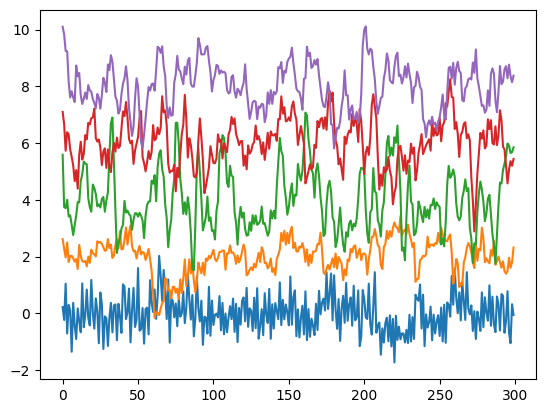

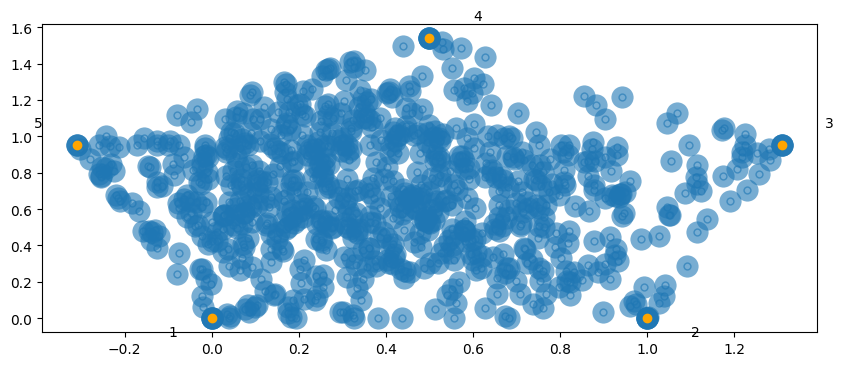

In [20]:
A=archs.transform(intact_array[0])
dp=archs.map2D
dat=dp @ A

f, ax = plt.subplots(figsize=(10, 4))
ax=archetypal_plot(ax,dat,dp,epsilon=.1)
ax.set_aspect('auto')
plt.show()

## Network Analysis

Let's load in what we need for our network analysis:

In [22]:
key = os.path.join('../data/raw/Schaefer2018_1000Parcels_7Networks_order.txt')
key = pd.read_csv(key, sep='\t', header=None, names=['id', 'name', 'x', 'y', 'z', 't']).drop('t', axis=1)
key['study'] = key['name'].apply(lambda x: x.split('_')[0])
key['hemisphere'] = key['name'].apply(lambda x: x.split('_')[1][0])
key['network'] = key['name'].apply(lambda x: x.split('_')[2])
key.drop('name', axis=1, inplace=True)

lookup_table = {
    'Vis': 'Visual',
    'SomMot': 'Somatomotor',
    'DorsAttn': 'Dorsal attention',
    'SalVentAttn': 'Ventral attention',
    'Limbic': 'Limbic',
    'Cont': 'Frontoparietal',
    'Default': 'Default mode'
}

network_colors = {
    'Visual': '#D7DF23',
    'Somatomotor': '#39B54A',
    'Dorsal attention': '#00A79D',
    'Ventral attention': '#27AAE1',
    'Limbic': '#1C75BC',
    'Frontoparietal': '#92278F',
    'Default mode': '#EE2A7B'
}

colors = ['#888888']
colors.extend([v for k, v in network_colors.items()])
network_cmap = ListedColormap(colors, N=len(colors)*2, name='networks')  # why do I need to double the number of colors?

network_codes = {k: i + 1 for i, k in enumerate(lookup_table.values())}

key['network'] = key['network'].apply(lambda x: lookup_table[x])
key['code'] = key['network'].apply(lambda x: network_codes[x])
key.set_index('id', inplace=True)
key.loc[0, 'code'] = 0  # append a background (non-network) code
key           # pip: nibabel==5.0.1

,x,y,z,study,hemisphere,network,code
id,,,,,,,
1,120.0,14.0,127.0,7Networks,L,Visual,1.0
2,120.0,14.0,128.0,7Networks,L,Visual,1.0
3,120.0,14.0,129.0,7Networks,L,Visual,1.0
4,120.0,14.0,130.0,7Networks,L,Visual,1.0
5,120.0,14.0,131.0,7Networks,L,Visual,1.0
...,...,...,...,...,...,...,...
997,208.0,65.0,82.0,7Networks,R,Default mode,7.0
998,208.0,65.0,83.0,7Networks,R,Default mode,7.0
999,235.0,149.0,37.0,7Networks,R,Frontoparietal,6.0


In [23]:
nii_fname = os.path.join('../data/raw/Schaefer2018_1000Parcels_7Networks_order_FSLMNI152_2mm.nii.gz')


So this is a plot of the 7 networks in the brain determined by Yeo et al. (2017).  

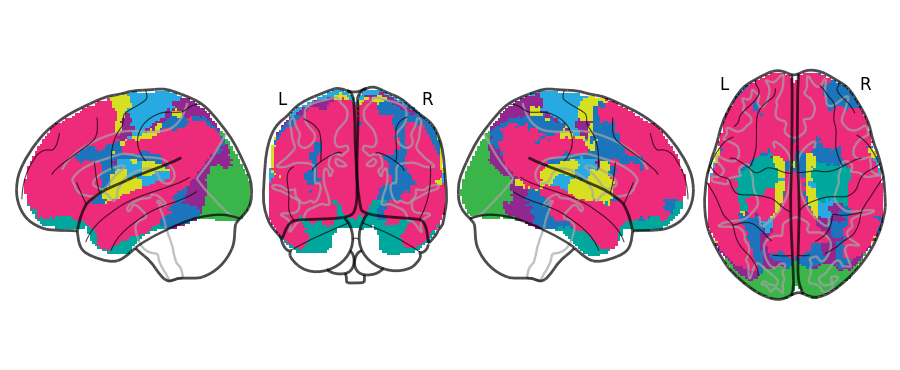

In [24]:
nx = nlt.Brain_Data(nii_fname)
nx.data = np.array([key.loc[i, 'code'] for i in nx.data]).astype(float)
networks = nx.to_nifti()

fname = os.path.join('networks.pdf')
nl.plotting.plot_glass_brain(networks, cmap=network_cmap, display_mode='lyrz', output_file=fname)
nl.plotting.plot_glass_brain(networks, cmap=network_cmap, display_mode='lyrz')
plt.show()
plt.clf()


We need a way to map our 700 nodes to these networks:

In [25]:
# load network parcellations in CMU format
networks_cmu = nii2cmu(nii_fname)

# covert voxel values in the reference image to network codes
networks_cmu['Y'] = np.atleast_2d(np.array([key.loc[i, 'code'] for i in networks_cmu['Y']]).astype(float))

And these are the labels/code for each of those nodes:

In [26]:
node_codes = node_labels(centers, widths, networks_cmu)
node_codes

,code,Network
0,4,Ventral attention
1,3,Dorsal attention
2,1,Visual
3,6,Frontoparietal
4,4,Ventral attention
...,...,...
695,2,Somatomotor
696,4,Ventral attention
697,4,Ventral attention
698,4,Ventral attention


Ok and plot that now (we could vary the node size relative to the width, but just for simplicity the nodes are all the same size here).

<Figure size 640x480 with 0 Axes>

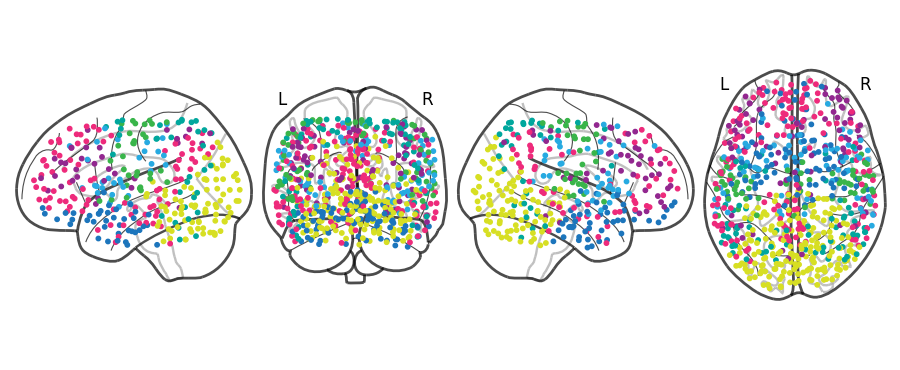

In [27]:
nl.plotting.plot_connectome(np.eye(centers.shape[0]), centers, node_size=10, node_color=[colors[i] for i in node_codes['code']], display_mode='lyrz', output_file=os.path.join('htfa.pdf'))
nl.plotting.plot_connectome(np.eye(centers.shape[0]), centers, node_size=10, node_color=[colors[i] for i in node_codes['code']], display_mode='lyrz')
plt.show()
plt.clf()

Ok now that we have the network labels for each of those nodes, lets see the overall count for each of those nodes in this dataset:

<Figure size 640x480 with 0 Axes>

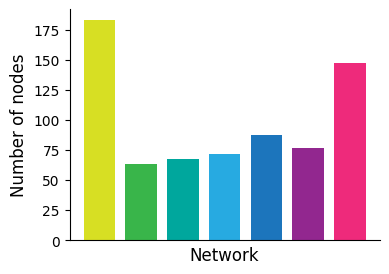

In [28]:
fig = plt.figure(figsize=(4, 3))
ax = plt.gca()

sns.histplot(data=node_codes, x='code', color='k', shrink=0.75, hue='code', hue_order=range(1, 8), palette=colors[1:], alpha=1.0, legend=False, ax=ax, discrete=True, edgecolor=None)
ax.set_xlabel('Network', fontsize=12)
ax.set_ylabel('Number of nodes', fontsize=12)

ax.set_xticks([])
ax.spines[['right', 'top']].set_visible(False)
plt.show()
plt.clf()
fig.savefig(os.path.join('htfa_node_counts.pdf'), bbox_inches='tight')

## Archetypes in 1 participant:

OK OK now back to the archetypal analysis... first let's just plot the timeseries and the corresponding nodes for the first archetype.  Remember, this is for that high frequency timeseries.

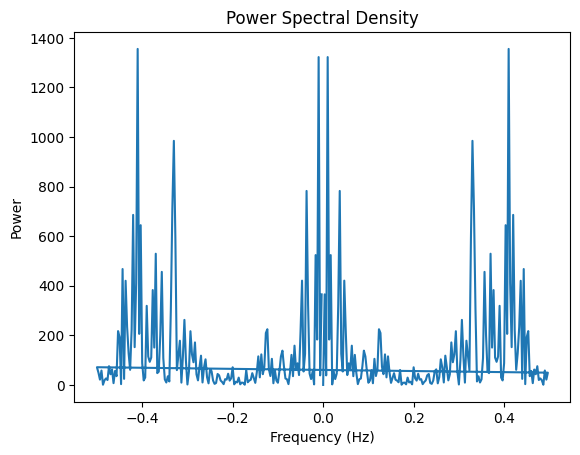

In [29]:
from scipy.fft import fft
signal = Z[:, 0]

fft_result = fft(signal)
frequencies = np.fft.fftfreq(len(signal))

psd = np.abs(fft_result)**2

# Plot PSD
plt.plot(frequencies, psd)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.title("Power Spectral Density")
plt.show()
plt.clf()

In [30]:
locs_arch_1 = A[0]>.75

In [31]:
arch_1_centers = centers[locs_arch_1]
arch_1_codes = node_codes['code'][locs_arch_1]
arch_1_nets = node_codes['Network'][locs_arch_1]

<Figure size 640x480 with 0 Axes>

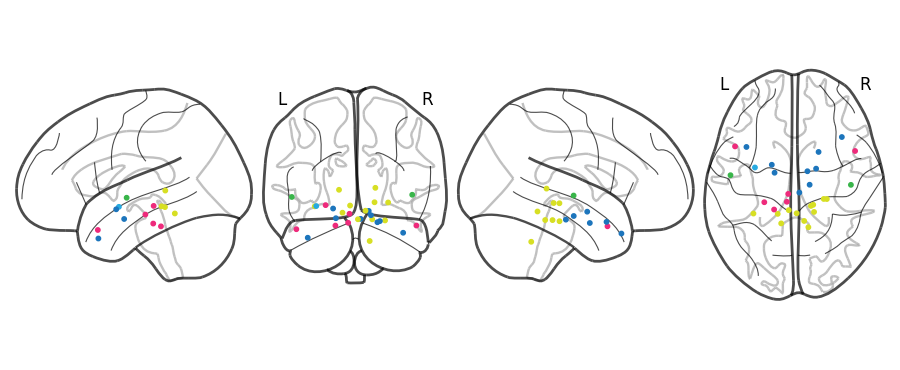

In [32]:
nl.plotting.plot_connectome(np.eye(arch_1_centers.shape[0]), arch_1_centers, node_size=10, node_color=[colors[i] for i in arch_1_codes], display_mode='lyrz')
plt.show()
plt.clf()

<Figure size 640x480 with 0 Axes>

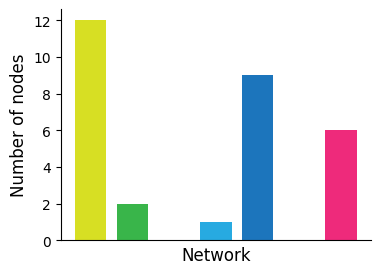

In [33]:
fig = plt.figure(figsize=(4, 3))
ax = plt.gca()

sns.histplot(data=node_codes[locs_arch_1], x='code', color='k', shrink=0.75, hue='code', hue_order=range(1, 8), palette=colors[1:], alpha=1.0, legend=False, ax=ax, discrete=True, edgecolor=None)
ax.set_xlabel('Network', fontsize=12)
ax.set_ylabel('Number of nodes', fontsize=12)

ax.set_xticks([])
ax.spines[['right', 'top']].set_visible(False)
plt.show()
plt.clf()

So this is interesting because it looks like the majority of these nodes are in the visual network... but you'll notice they are in the high level visual processing areas... as well as ventral attention and default mode.

Here's the same figures but for the second archetype... this has a slower frequency with a large dip around the 2 minute mark (this data was collected using 2 TRs, so the total time is 10 minutes).

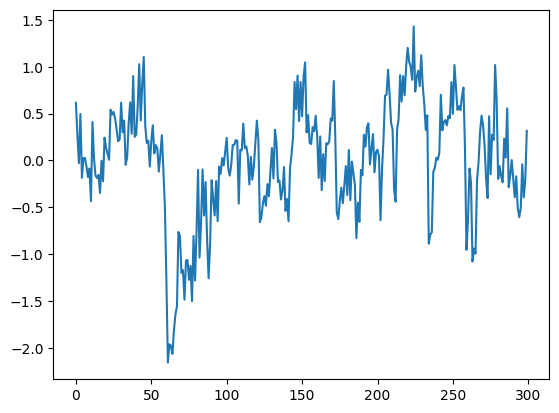

In [34]:
plt.plot(Z[:, 1])
plt.show()
plt.clf()

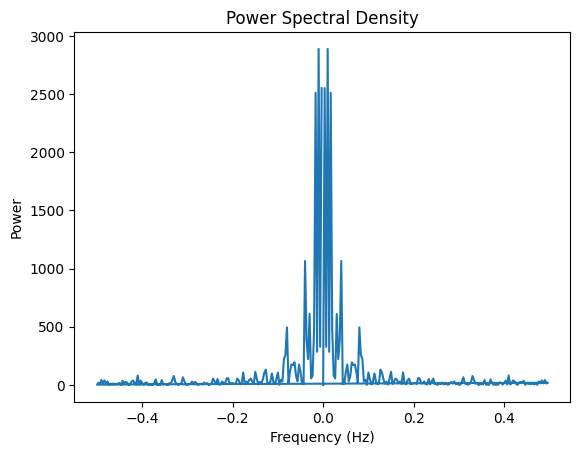

In [35]:
signal = Z[:, 1]

fft_result = fft(signal)
frequencies = np.fft.fftfreq(len(signal))

psd = np.abs(fft_result)**2

# Plot PSD
plt.plot(frequencies, psd)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.title("Power Spectral Density")
plt.show()
plt.clf()

In [36]:
locs_arch_2 = A[1]>.75

In [37]:
arch_2_centers = centers[locs_arch_2]
arch_2_codes = node_codes['code'][locs_arch_2]
arch_2_nets = node_codes['Network'][locs_arch_2]

<Figure size 640x480 with 0 Axes>

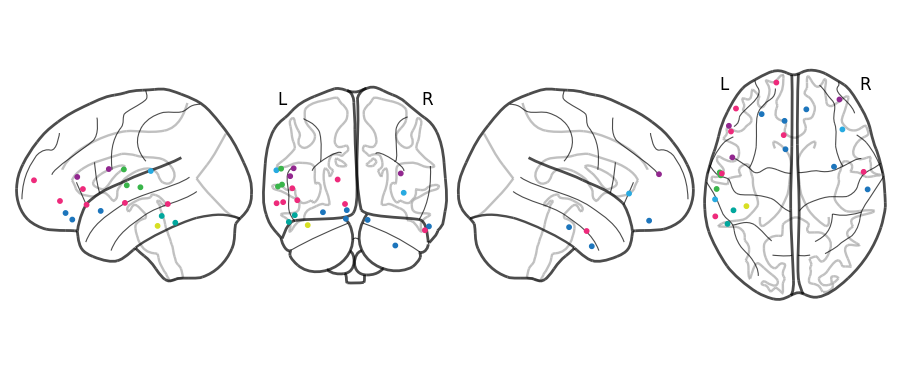

In [38]:
nl.plotting.plot_connectome(np.eye(arch_2_centers.shape[0]), arch_2_centers, node_size=10, node_color=[colors[i] for i in arch_2_codes], display_mode='lyrz')
plt.show()
plt.clf()

<Figure size 640x480 with 0 Axes>

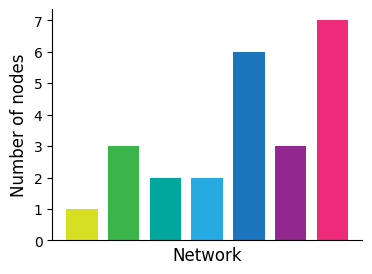

In [39]:
fig = plt.figure(figsize=(4, 3))
ax = plt.gca()

sns.histplot(data=node_codes[locs_arch_2], x='code', color='k', shrink=0.75, hue='code', hue_order=range(1, 8), palette=colors[1:], alpha=1.0, legend=False, ax=ax, discrete=True, edgecolor=None)
ax.set_xlabel('Network', fontsize=12)
ax.set_ylabel('Number of nodes', fontsize=12)

ax.set_xticks([])
ax.spines[['right', 'top']].set_visible(False)
plt.show()
plt.clf()

Looks like the majority of the nodes are in, again, the ventral attention and default mode networks. This is also picking up on *left* hemispheric nodes, particularly in the somatomotor network, and it really looks like they are in the speech and language processing areas!


Ok lets do it for the third archetype:

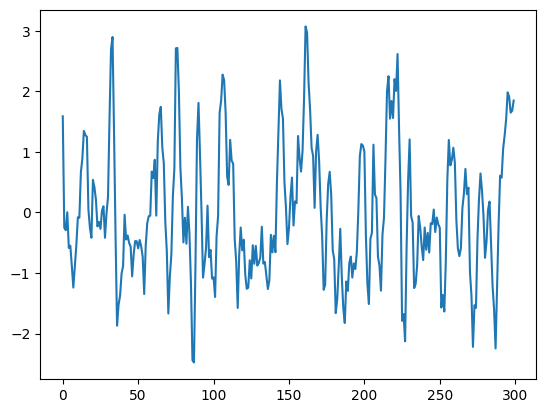

In [40]:
plt.plot(Z[:, 2])
plt.show()
plt.clf()

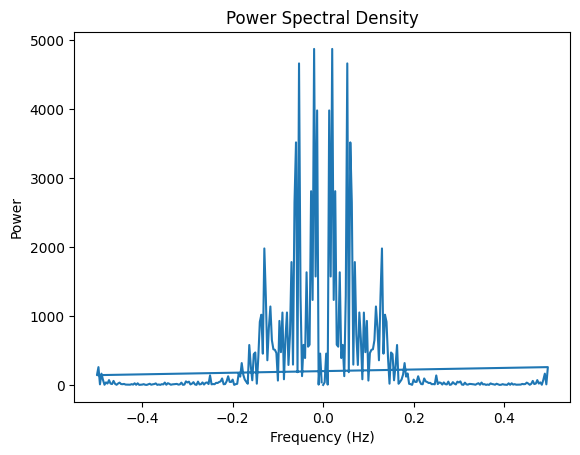

In [41]:
from scipy.fft import fft
signal = Z[:, 2]

fft_result = fft(signal)
frequencies = np.fft.fftfreq(len(signal))

psd = np.abs(fft_result)**2

# Plot PSD
plt.plot(frequencies, psd)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.title("Power Spectral Density")
plt.show()
plt.clf()

This is a very slow, variable signal... hmmm.. if we go this route with the timeseries I need to dig up a better way of quantifying these signals.  

In [42]:
locs_arch_3 = A[2]>.75
arch_3_centers = centers[locs_arch_3]
arch_3_codes = node_codes['code'][locs_arch_3]
arch_3_nets = node_codes['Network'][locs_arch_3]

<Figure size 640x480 with 0 Axes>

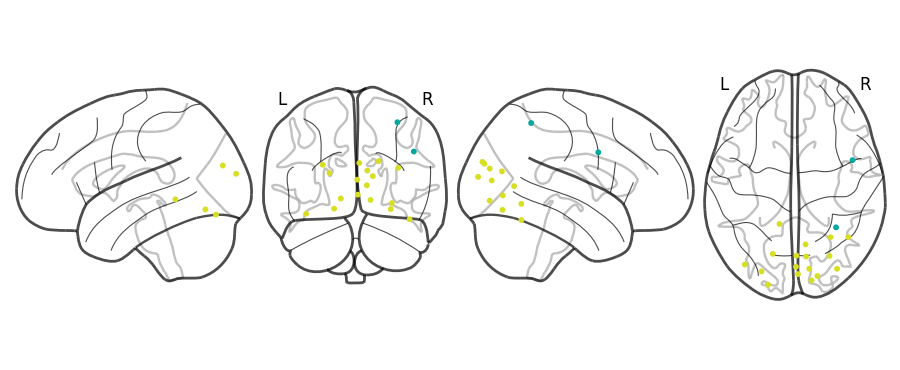

In [43]:
nl.plotting.plot_connectome(np.eye(arch_3_centers.shape[0]), arch_3_centers, node_size=10, node_color=[colors[i] for i in arch_3_codes], display_mode='lyrz')
plt.show()
plt.clf()

<Figure size 640x480 with 0 Axes>

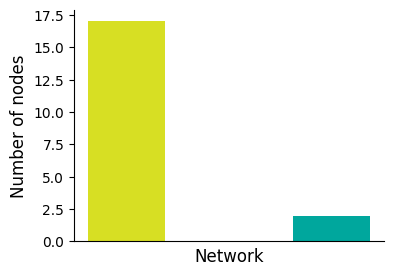

In [44]:
fig = plt.figure(figsize=(4, 3))
ax = plt.gca()

sns.histplot(data=node_codes[locs_arch_3], x='code', color='k', shrink=0.75, hue='code', hue_order=range(1, 8), palette=colors[1:], alpha=1.0, legend=False, ax=ax, discrete=True, edgecolor=None)
ax.set_xlabel('Network', fontsize=12)
ax.set_ylabel('Number of nodes', fontsize=12)

ax.set_xticks([])
ax.spines[['right', 'top']].set_visible(False)
plt.show()
plt.clf()

This ones cool, because it is almost entirely in the visual network.

Ok on to the fourth:

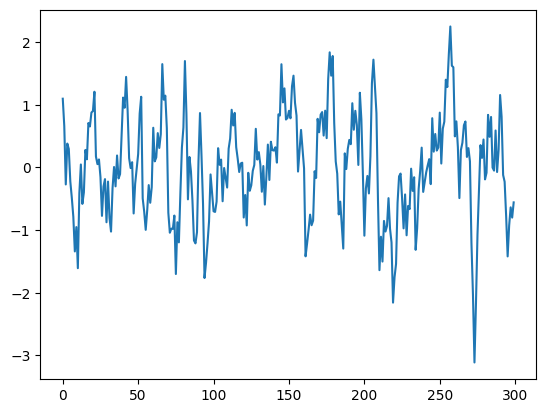

In [45]:
plt.plot(Z[:, 3])
plt.show()
plt.clf()

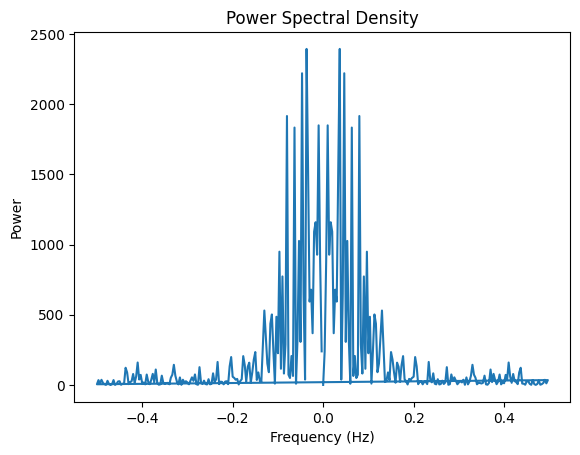

In [46]:
signal = Z[:, 3]

fft_result = fft(signal)
frequencies = np.fft.fftfreq(len(signal))

psd = np.abs(fft_result)**2

# Plot PSD
plt.plot(frequencies, psd)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.title("Power Spectral Density")
plt.show()
plt.clf()

In [47]:
locs_arch_4 = A[3]>.75
arch_4_centers = centers[locs_arch_4]
arch_4_codes = node_codes['code'][locs_arch_4]
arch_4_nets = node_codes['Network'][locs_arch_4]

<Figure size 640x480 with 0 Axes>

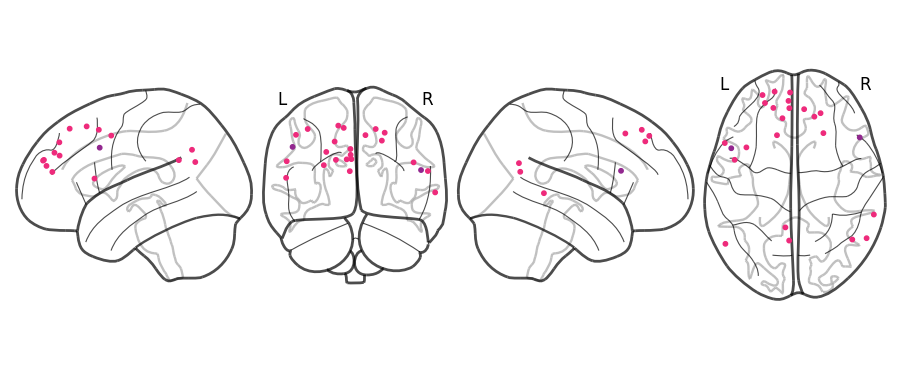

In [48]:
nl.plotting.plot_connectome(np.eye(arch_4_centers.shape[0]), arch_4_centers, node_size=10, node_color=[colors[i] for i in arch_4_codes], display_mode='lyrz')
plt.show()
plt.clf()

<Figure size 640x480 with 0 Axes>

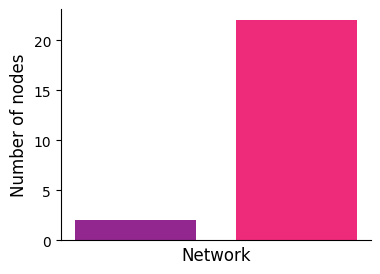

In [49]:
fig = plt.figure(figsize=(4, 3))
ax = plt.gca()

sns.histplot(data=node_codes[locs_arch_4], x='code', color='k', shrink=0.75, hue='code', hue_order=range(1, 8), palette=colors[1:], alpha=1.0, legend=False, ax=ax, discrete=True, edgecolor=None)
ax.set_xlabel('Network', fontsize=12)
ax.set_ylabel('Number of nodes', fontsize=12)

ax.set_xticks([])
ax.spines[['right', 'top']].set_visible(False)
plt.show()
plt.clf()

This is almost entirely in the default mode network! Ok and now the last one:

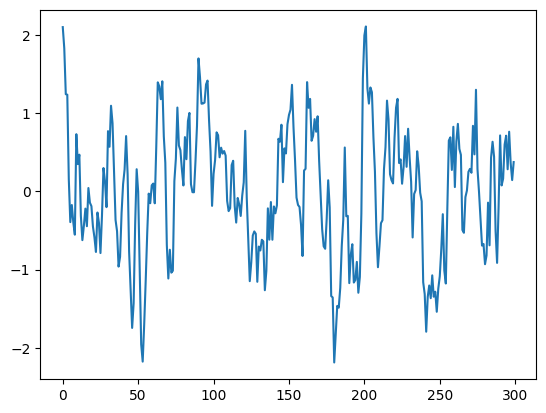

In [50]:
plt.plot(Z[:, 4])
plt.show()
plt.clf()

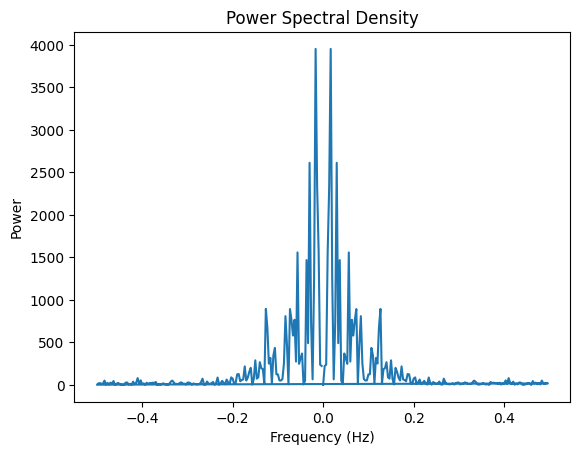

In [51]:
signal = Z[:, 4]

fft_result = fft(signal)
frequencies = np.fft.fftfreq(len(signal))

psd = np.abs(fft_result)**2

# Plot PSD
plt.plot(frequencies, psd)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.title("Power Spectral Density")
plt.show()
plt.clf()

In [52]:
locs_arch_5 = A[4]>.75
arch_5_centers = centers[locs_arch_5]
arch_5_codes = node_codes['code'][locs_arch_5]
arch_5_nets = node_codes['Network'][locs_arch_5]

<Figure size 640x480 with 0 Axes>

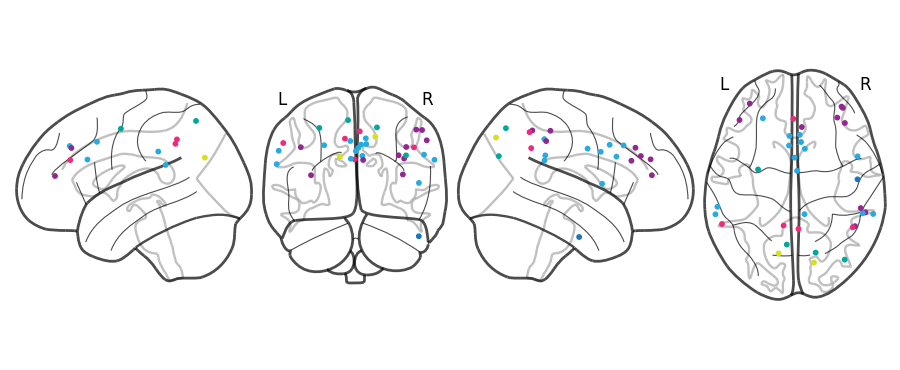

In [53]:
nl.plotting.plot_connectome(np.eye(arch_5_centers.shape[0]), arch_5_centers, node_size=10, node_color=[colors[i] for i in arch_5_codes], display_mode='lyrz')
plt.show()
plt.clf()

<Figure size 640x480 with 0 Axes>

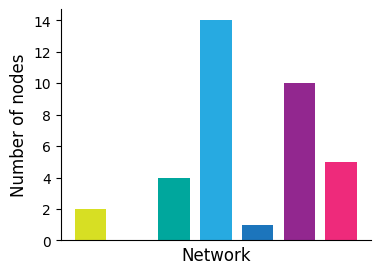

In [54]:
fig = plt.figure(figsize=(4, 3))
ax = plt.gca()

sns.histplot(data=node_codes[locs_arch_5], x='code', color='k', shrink=0.75, hue='code', hue_order=range(1, 8), palette=colors[1:], alpha=1.0, legend=False, ax=ax, discrete=True, edgecolor=None)
ax.set_xlabel('Network', fontsize=12)
ax.set_ylabel('Number of nodes', fontsize=12)

ax.set_xticks([])
ax.spines[['right', 'top']].set_visible(False)
plt.show()
plt.clf()

Kind of a smattering, but mainly in the ventral attention, frontoparietal (control), and default mode networks. Overall, very cool!

Ok so now follow up ideas to this analysis:
- look at the optimal number of archetypes (scree plot)
  - this could be done by participant and maybe the more archetypes corresponds with more complex data... or the opposite?? Hmm?

- Figure out how to perform this analysis but across particpants... but i'm assuming that each particpant with have different networks for each archetype.... so maybe look at the average first archetype, second, third??? Seems like theres a better way!
- Ultimately it would be nice to run this with some sort of difference in behavior or strategy across a group.... so something where these participants brains look like this becuase theyre performing this strategy

### Ok now lets try the same thing... but this time of the characteristic *nodes* by transposing the input data

RSS = 490.8364772665991
RSS = 471.66381246677236
RSS = 465.4132599100641
RSS = 463.01233957098646
RSS = 461.4736327012386
RSS = 460.12604161761436
RSS = 459.26758579819364
RSS = 458.7769873772427
RSS = 458.527153522485
RSS = 458.39394461701653


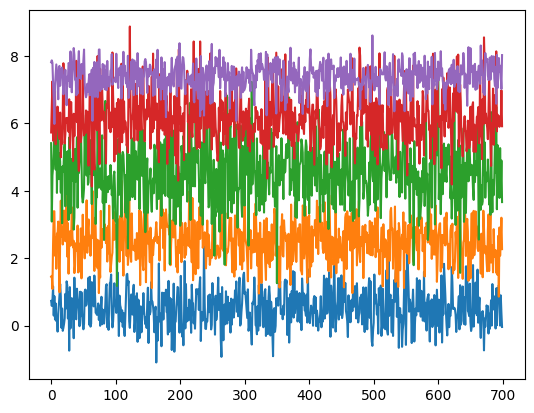

In [57]:
archs = ArchetypalAnalysis(n_archetypes=5,iterations=10,tmax=300)

archs.fit(intact_array[0].T)

Z=(archs.archetypes())

for i in np.arange(5):
  plt.plot(Z[:, i]+ 2*i)

plt.show()
plt.clf()

In [58]:
A=archs.transform(intact_array[0].T)

In [59]:
A.shape

(5, 300)

<Figure size 640x480 with 0 Axes>

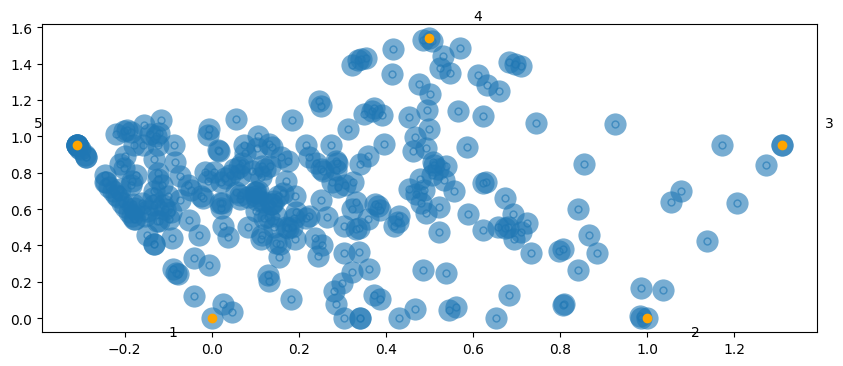

In [60]:
A=archs.transform(intact_array[0].T)
dp=archs.map2D
dat=dp @ A

f, ax = plt.subplots(figsize=(10, 4))
ax=archetypal_plot(ax,dat,dp,epsilon=.1)
ax.set_aspect('auto')
plt.show()

Does the shape of this mean anything?  The distribution seems curiously unbalanced

In [61]:
times_arch_1 = archs.A_[0]>.5

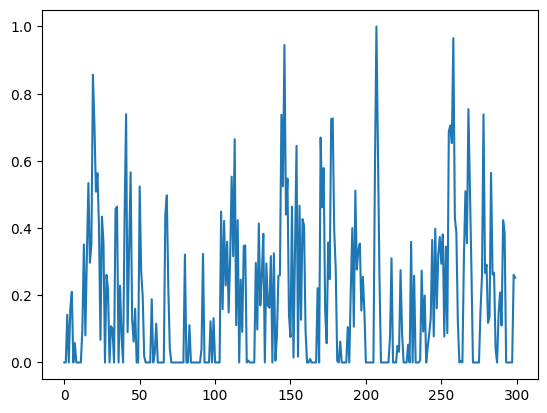

In [62]:
plt.plot(archs.A_[0])
plt.show()
plt.clf()

<Figure size 640x480 with 0 Axes>

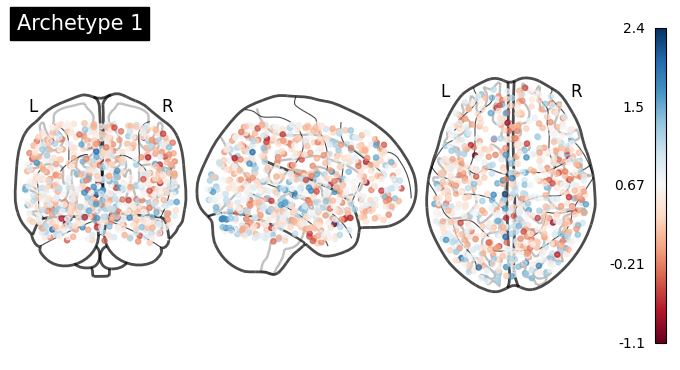

In [66]:
nl.plotting.plot_markers(
    Z[:, 0],
    centers,
    title="Archetype 1",
    node_cmap=cm.RdBu,
)
plt.show()
plt.clf()

In [67]:
times_arch_2 = archs.A_[1]>.75

<Figure size 640x480 with 0 Axes>

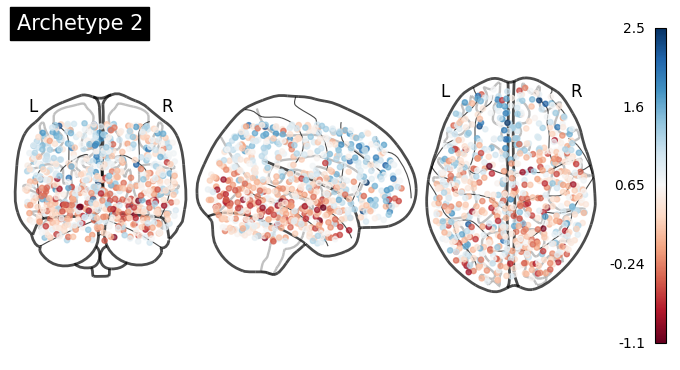

In [68]:
nl.plotting.plot_markers(
    Z[:, 1],
    centers,
    title="Archetype 2",
    node_cmap=cm.RdBu,
)
plt.show()
plt.clf()

In [69]:
times_arch_3 = archs.A_[2]>.75

<Figure size 640x480 with 0 Axes>

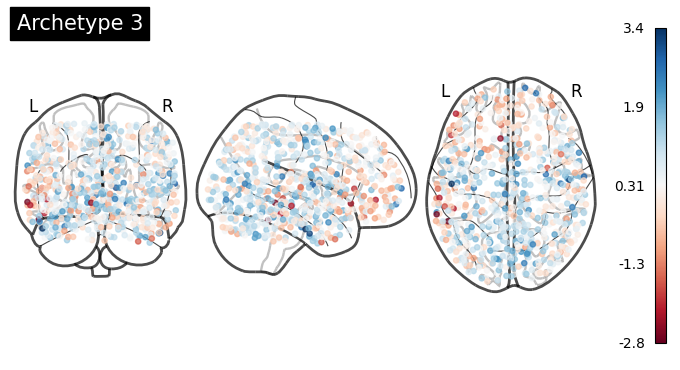

In [70]:
nl.plotting.plot_markers(
    Z[:, 2],
    centers,
    title="Archetype 3",
    node_cmap=cm.RdBu,
)
plt.show()
plt.clf()

In [71]:
times_arch_4 = archs.A_[3]>.7

<Figure size 640x480 with 0 Axes>

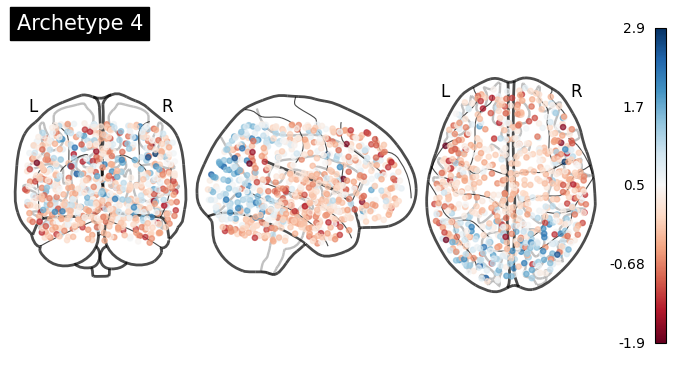

In [72]:
nl.plotting.plot_markers(
    Z[:, 3],
    centers,
    title="Archetype 4",
    node_cmap=cm.RdBu,
)
plt.show()
plt.clf()

In [73]:
times_arch_5 = archs.A_[4]>.75

<Figure size 640x480 with 0 Axes>

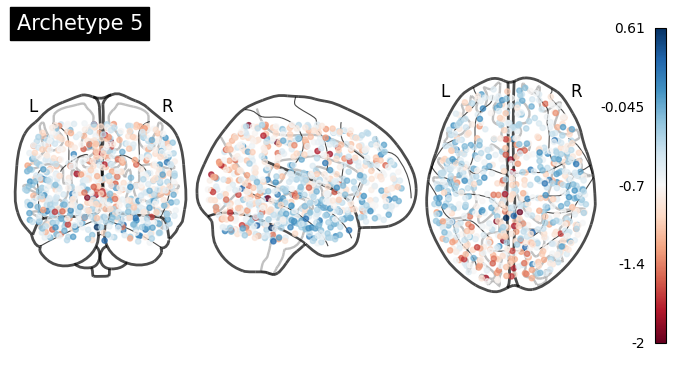

In [74]:
nl.plotting.plot_markers(
    Z[:, 4],
    centers,
    title="Archetype 5",
    node_cmap=cm.RdBu,
)
plt.show()
plt.clf()

Ok... now I want to make a video of that moving!  I want each of the 5 archetypes with the opacity by the coefficient

In [76]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import io
from IPython.display import display

# Function to create a frame
def create_frame(i, J, n_frames):
    plt.clf() # Clear current plot
    fig, axes = plt.subplots(nrows=J+1, ncols=1, figsize=(14, 20))

    # Modify data or plot parameters based on 'i' (for loop iteration)
    # Example: animate adding markers over time
    
    for j, ax in enumerate(axes.flatten()):
        if j != J:
            nl.plotting.plot_markers(Z[:, j], centers, alpha=A[j, i], title="Archetype " + str(j + 1), node_cmap=cm.RdBu, axes = ax) # Your nl.plotting.plot_markers call
        # Plot the horizontal line
        else:
            ax.plot([0, n_frames], [.5, .5], color='black', linestyle='--', label=f'Horizontal Line at y={.5}')
            
            ax.plot(i, .5, marker='o', color='red')
            
            # Remove the border (spines) from the plot
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.spines['bottom'].set_visible(False)
            ax.spines['left'].set_visible(False)
            
            # Optional: Remove ticks and labels if desired
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_title('Timeline',
                         fontweight ="bold")

    buf = io.BytesIO()
    plt.savefig(buf, format='png')
    buf.seek(0)
    return Image.open(buf)

# Collect frames in a loop
frames = []
n_frames = A.shape[1]
for i in range(n_frames):
# for i in range(A.shape[1]): # Adjust range for number of frames
    frames.append(create_frame(i, A.shape[0], n_frames))

# Create and save the animated GIF
frames[0].save(
    'markers_animation.gif',
    save_all=True,
    append_images=frames[1:],
    duration=200, # Adjust duration in milliseconds
    loop=0 # 0 means infinite loop
)




/var/folders/4j/wgxcnp1d5kx_wk4b7vtwn_ww0000gn/T/ipykernel_11644/3925208090.py:10: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(nrows=J+1, ncols=1, figsize=(14, 20))
